# RL for Resource Optimization

## 📚 Learning Objectives

By completing this notebook, you will:
- Use RL for resource allocation or scheduling
- Define state, action, and reward for the domain

## 🔗 Prerequisites

- ✅ Basic Python
- ✅ Basic NumPy/Pandas (when applicable)

---

## Official Structure Reference

This notebook belongs to **Course 09, Unit 5**.

---


## Lesson Brief

This lesson frames resource allocation as a sequential decision problem.

Students will see how an RL agent can balance service quality against wasted capacity when demand changes over time.

Why this matters: this is one of the most important examples showing that RL can be useful in operations, infrastructure, and control.

The key learning goal is to connect RL to real adaptive decision-making beyond games.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## Recommended YouTube Video

To reinforce this lesson, watch **David Silver - "RL Course Lecture 9: Exploration and Exploitation"**:
[Watch on YouTube](https://www.youtube.com/watch?v=sGuiWX07sKw)

Why this pick:
- Resource optimization often reduces to choosing under uncertainty while managing limited opportunities.
- This video gives the best conceptual foundation for allocation-style RL reasoning, even when the example is simpler than a full operations problem.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Allocation: deciding where limited resources go.
- Constraint-aware action: valid under limits.
- Efficiency objective: gain minus waste.
- Trade-off: improving one thing may hurt another.
- Delayed operational effect: a choice now can change later system pressure.

### Quick Check
- What exactly is the agent optimizing?
- How do constraints shape the action space?
- Why is repeated decision-making important here?
- Why is a greedy one-step choice sometimes not enough?

### Common Mistakes
- Ignoring constraints.
- Using rewards that miss cost.
- Assuming a locally good action is globally good.
- Forgetting that demand changes over time, so the best action can depend on future load.


## Why Resource Optimization Is More Than a Static Math Problem

Students often first see allocation as a one-time optimization problem.
This notebook is useful because it shows when the problem becomes sequential instead.

### Static optimization view

If demand, supply, and costs were fixed once, a classical optimizer might be enough.

### RL view

RL becomes more relevant when:

- demand changes over time
- actions affect future system state
- short-term savings can create long-term cost or risk

### Teaching takeaway

This notebook is not claiming RL replaces all optimization.
It is showing the narrower but important case where allocation becomes a repeated decision problem under changing conditions.

## Inputs and Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---


### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [1]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt
# Show text or numbers in the cell output area under the code.
print('✅ Setup complete!')


✅ Setup complete!


## Part 1: Resource Allocation Problem


### Step Guide

**What this cell does:** Follow the printed section: "Example observed state:"

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [2]:
# Model definition: this class packages one core RL concept into a reusable object.
# Read its state, methods, and update rules together so the algorithm feels concrete.

# Class `ResourceAllocationEnv` (what it does): A tiny environment sketch for thinking about resource allocation.
class ResourceAllocationEnv:
    """A tiny environment sketch for thinking about resource allocation."""

    # Function `__init__` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, demand_level.
    def __init__(self, demand_level=0):
        # Save a value in a name so the next lines can read it.
        self.demand_level = demand_level

    # Function `observe` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self.
    def observe(self):
        # Send a value back to whoever called this function.
        return {"demand_level": self.demand_level}


# Save a value in a name so the next lines can read it.
env = ResourceAllocationEnv(demand_level=2)
# Show text or numbers in the cell output area under the code.
print("Example observed state:", env.observe())


Example observed state: {'demand_level': 2}


## Part 2: Q-Learning for Resource Optimization


### Step Guide

**What this cell does:** Build the next chunk of the lesson (often a function, table, or training loop).

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [3]:
# Teaching note: this cell advances the lesson by building the next piece of the RL workflow.
# Run it after reading the comments so the output feels connected to the concept being taught.

# Example action meanings for a resource allocator
# Create the list of action names (their indices are the numeric action ids).
ACTIONS = {
    # Execute: 0: "low capacity",
    0: "low capacity",
    # Execute: 1: "medium capacity",
    1: "medium capacity",
    # Execute: 2: "high capacity",
    2: "high capacity",
# Part of a dict/set literal layout (syntax grouping).
}

# Show text or numbers in the cell output area under the code.
print("Possible resource-allocation actions:")
# Start a loop: repeat the indented block once per item in the sequence.
for action_id, label in ACTIONS.items():
    # Show text or numbers in the cell output area under the code.
    print(f"  {action_id}: {label}")


Possible resource-allocation actions:
  0: low capacity
  1: medium capacity
  2: high capacity


## Real-World Applications

- **Data Centers**: Google DeepMind reduced energy use with adaptive control
- **Energy Grids**: Load balancing and demand response
- **Cloud Computing**: Auto-scaling and resource allocation
- **Manufacturing**: Production line optimization

### Why this lesson matters

This topic helps students see that RL is not only for games. It is also useful
when a system must repeatedly allocate limited resources under changing demand.

## Worked Example: Server Capacity as a Sequential Decision Problem

Resource optimization is a good RL application when decisions must adapt over time.

Imagine a service that can run in three capacity modes:
- low capacity
- medium capacity
- high capacity

If demand rises and capacity is too low, users wait and the reward drops.
If capacity is too high when demand is low, energy is wasted.

That trade-off is exactly the kind of sequential balancing problem RL can model.

### Step Guide

**What this cell does:** Summarize or compare results (policies, returns, tables) for the lesson goal.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Tables, arrays, or comparison prints showing which policy or method wins.

**If you feel lost:** If output is empty, run the previous cells that define the data this cell consumes.


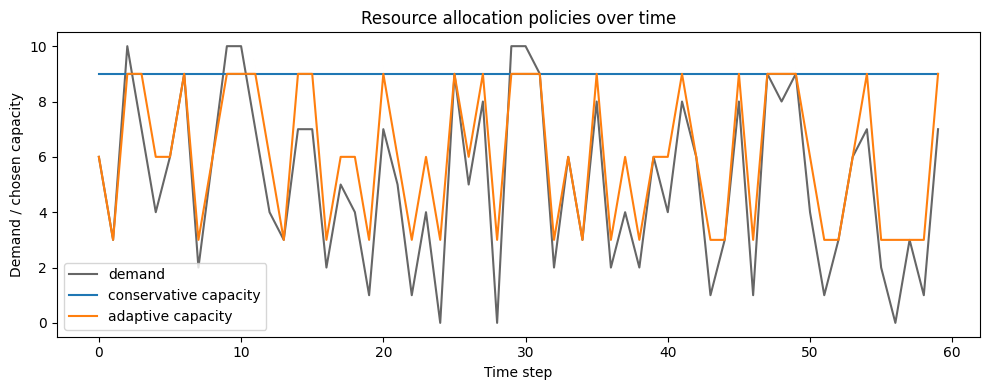

Average reward with conservative policy: 7.83
Average reward with adaptive policy:     9.31

Teaching point:
Resource optimization is sequential because the system must repeatedly balance
under-provisioning against over-provisioning as demand changes over time.


In [4]:
# Final computation: this cell usually summarizes the lesson, evaluates the result, or compares strategies.
# Pause here and ask what the numbers or tables say about the decision-making process.

# Use NumPy for fast numeric arrays and math on grids of numbers.
np.random.seed(42)
# Save a value in a name so the next lines can read it.
demand = np.random.randint(0, 11, size=60)
# Another assignment—same idea: store a value for the lines below.
capacity_levels = {0: 3, 1: 6, 2: 9}


# Function `reward_for` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: capacity_action, current_demand.
def reward_for(capacity_action, current_demand):
    # Save a value in a name so the next lines can read it.
    capacity = capacity_levels[capacity_action]
    # Another assignment—same idea: store a value for the lines below.
    unmet = max(current_demand - capacity, 0)
    # Another assignment—same idea: store a value for the lines below.
    waste = max(capacity - current_demand, 0)
    # Send a value back to whoever called this function.
    return 10 - 2 * unmet - 0.5 * waste


# Function `conservative_policy` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: current_demand.
def conservative_policy(current_demand):
    # Send a value back to whoever called this function.
    return 2


# Function `adaptive_policy` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: current_demand.
def adaptive_policy(current_demand):
    # If the condition is True, run the indented block under this line.
    if current_demand <= 3:
        # Send a value back to whoever called this function.
        return 0
    # If the condition is True, run the indented block under this line.
    if current_demand <= 6:
        # Send a value back to whoever called this function.
        return 1
    # Send a value back to whoever called this function.
    return 2


# Save a value in a name so the next lines can read it.
conservative_rewards = [reward_for(conservative_policy(d), d) for d in demand]
# Another assignment—same idea: store a value for the lines below.
adaptive_rewards = [reward_for(adaptive_policy(d), d) for d in demand]

# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.figure(figsize=(10, 4))
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.plot(demand, label="demand", color="black", alpha=0.6)
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.plot([capacity_levels[conservative_policy(d)] for d in demand], label="conservative capacity")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.plot([capacity_levels[adaptive_policy(d)] for d in demand], label="adaptive capacity")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.xlabel("Time step")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.ylabel("Demand / chosen capacity")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.title("Resource allocation policies over time")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.legend()
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.tight_layout()
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.show()

# Show text or numbers in the cell output area under the code.
print("Average reward with conservative policy:", round(np.mean(conservative_rewards), 2))
# Show text or numbers in the cell output area under the code.
print("Average reward with adaptive policy:    ", round(np.mean(adaptive_rewards), 2))

# Show text or numbers in the cell output area under the code.
print("\nTeaching point:")
# Show text or numbers in the cell output area under the code.
print("Resource optimization is sequential because the system must repeatedly balance")
# Show text or numbers in the cell output area under the code.
print("under-provisioning against over-provisioning as demand changes over time.")


In [5]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References & Further Reading

### Books
- Sutton & Barto — [Reinforcement Learning: An Introduction](http://incompleteideas.net/book/the-book-2nd.html)

**Examples and Context:**
- Google DeepMind — [Data centre cooling with AI](https://deepmind.google/discover/blog/deepmind-ai-reduces-google-data-centre-cooling-bill-by-40/)
- RL for operations, scheduling, and control is a common applied pattern in modern industry

**Teaching note:**
Resource optimization often combines forecasting, control, and RL-style sequential decision making.
"""))


## 📚 References & Further Reading

### Books
- Sutton & Barto — [Reinforcement Learning: An Introduction](http://incompleteideas.net/book/the-book-2nd.html)

**Examples and Context:**
- Google DeepMind — [Data centre cooling with AI](https://deepmind.google/discover/blog/deepmind-ai-reduces-google-data-centre-cooling-bill-by-40/)
- RL for operations, scheduling, and control is a common applied pattern in modern industry

**Teaching note:**
Resource optimization often combines forecasting, control, and RL-style sequential decision making.


## Summary

This notebook framed resource optimization as an RL-style decision problem:

- the state includes changing demand or workload
- the action controls how many resources to allocate
- the reward balances service quality against waste or energy cost

### Main takeaway

RL becomes attractive when resource decisions must adapt repeatedly under
uncertainty, not just be optimized once.

### Step Guide

**What this cell does:** Try to auto-plot lesson numbers already in memory (optional recap charts).

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Either one or more plots, or a short message that nothing was auto-plotted.

**If you feel lost:** Re-run the main lesson cells so numeric variables exist, then try this recap again.


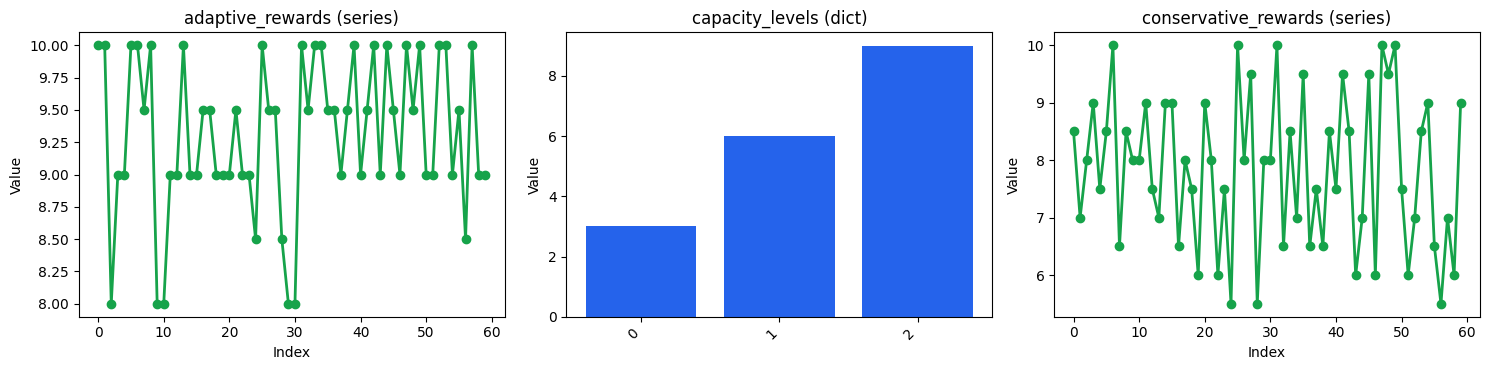

In [6]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
# Load a library so you can use its ready-made functions and types below.
import numbers
# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Function `_is_number` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _is_number(value):
    # Send a value back to whoever called this function.
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

# Function `_as_numeric_dict` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _as_numeric_dict(value):
    # If the condition is True, run the indented block under this line.
    if not isinstance(value, dict) or not value or len(value) > 12:
        # Send a value back to whoever called this function.
        return None
    # Collect numeric dict values after validation for plotting.
    converted = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for item in value.values():
        # If the condition is True, run the indented block under this line.
        if not _is_number(item):
            # Send a value back to whoever called this function.
            return None
        # Add one new item to the end of a list (the list grows in place).
        converted.append(float(item))
    # Send a value back to whoever called this function.
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

# Function `_as_numeric_array` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value, dims.
def _as_numeric_array(value, dims):
    # Try/except/finally: structured error handling around risky operations.
    try:
        # Temporary ndarray after coercion attempt inside _as_numeric_array().
        array = np.asarray(value, dtype=float)
    # Try/except/finally: structured error handling around risky operations.
    except Exception:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if array.ndim != dims:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 1 and not (2 <= array.size <= 200):
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 2 and array.size > 400:
        # Send a value back to whoever called this function.
        return None
    # Send a value back to whoever called this function.
    return array

# Preferred global names to try first when auto-picking lesson plots.
priority_names = [
    # Execute: "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    # Execute: "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores …
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
# Execute: ]
]

# Names that are never lesson metrics (imports / plotting handles).
skip_names = {"np", "plt", "numbers", "math", "Figure", "fig"}
# Save a value in a name so the next lines can read it.
candidates = []
# Track which names were already visited to avoid duplicates.
seen = set()
# Ordered list of global names to scan for plottable numeric artifacts.
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

# Start a loop: repeat the indented block once per item in the sequence.
for name in search_space:
    # If the condition is True, run the indented block under this line.
    if name in seen or name not in globals() or name in skip_names:
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue
    # Execute: seen.add(name)
    seen.add(name)
    # The runtime object bound to that global name.
    value = globals()[name]

    # Try to interpret a global variable as a plottable payload (or None if not).
    dict_payload = _as_numeric_dict(value)
    # If the condition is True, run the indented block under this line.
    if dict_payload is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("dict", name, dict_payload))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_2d = _as_numeric_array(value, 2)
    # If the condition is True, run the indented block under this line.
    if array_2d is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("heatmap", name, array_2d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_1d = _as_numeric_array(value, 1)
    # If the condition is True, run the indented block under this line.
    if array_1d is not None:
        # Append one value to a list (mutates the list in place).
        # Skip misleading line plots for last-step env vectors (not time series).
        # If the condition is True, run the indented block under this line.
        if name in {"obs", "next_obs", "state", "action"} and array_1d.size <= 16:
            # Skip to the next lap of the loop (ignore the rest of this lap).
            continue
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("line", name, array_1d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break

# If the condition is True, run the indented block under this line.
if not candidates:
    # Build a small dict used only for the fallback summary bar chart.
    summary = {
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "functions": sum(callable(value) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "classes": sum(isinstance(value, type) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    # Part of a dict/set literal layout (syntax grouping).
    }
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, ax = plt.subplots(figsize=(6, 3.5))
    # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_title("Notebook artifact summary")
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_ylabel("Count")
    # Start a loop: repeat the indented block once per item in the sequence.
    for idx, value in enumerate(summary.values()):
        # Same plot panel as the line above—one more small plotting tweak.
        ax.text(idx, value + 0.05, str(value), ha="center")
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()
# Else: run this block when none of the if/elif tests above matched.
else:
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    # If the condition is True, run the indented block under this line.
    if len(candidates) == 1:
        # Save a value in a name so the next lines can read it.
        axes = [axes]

    # Start a loop: repeat the indented block once per item in the sequence.
    for ax, (kind, name, payload) in zip(axes, candidates):
        # If the condition is True, run the indented block under this line.
        if kind == "dict":
            # Unpack plotting payload for dict bar charts (keys vs numeric values).
            labels, values = payload
            # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
            ax.bar(range(len(values)), values, color="#2563eb")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticks(range(len(values)))
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticklabels(labels, rotation=45, ha="right")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (dict)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else-if: only checked when the earlier if/elif tests were False.
        elif kind == "line":
            # Same plot panel as the line above—one more small plotting tweak.
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (series)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xlabel("Index")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else: run this block when none of the if/elif tests above matched.
        else:
            # Image handle returned by imshow for attaching a colorbar.
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (heatmap)")
            # Change something about the whole figure (not just one small subplot).
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()


## Closing Takeaway

**Teaching takeaway:** Resource optimization frames RL as a repeated trade-off between immediate cost, service quality, and future flexibility.

**If students remember one idea:** In practical systems, the reward often reflects competing goals rather than a single simple objective.

**Quick check before moving on:**
- Can you explain which decisions the agent controls in this optimization problem?
- Can you describe how the reward encodes trade-offs like cost versus performance?

**Bridge to the next step:** The next lesson expands the setting from one agent to multiple agents that must cooperate or compete.

**For weaker coders:** After you run the important cells, write one sentence: *what number or plot changed, and does that match what the lesson said should happen?* If not, re-read only the `#` hint lines in that cell—not every line of Python.


## Motion recap (optional)

**Why this cell exists:** many RL ideas are easiest to sanity-check when you can **watch time unfold** — a state changes because an action was taken, then a reward signal arrives.

**FrozenLake here is a shared toy picture** (not the “whole story” of every method in this notebook):
- Treat it as a **concrete instance** of the vocabulary you already used: **state** = which tile, **action** = move direction, **reward** = goal / hole / step, **episode** = from start until stop.

**Map this picture to your lesson (pick what fits):**
- **MDPs / value iteration / DP ideas:** ask what a “good tile” should be worth *on the way* to the goal, and what a hole implies for long-horizon returns.
- **Policy evaluation / Monte Carlo / TD / Q-learning / SARSA:** relate the moves you see to **estimated values or Q(s,a)** and to the **backup** idea you implemented above.
- **Exploration vs exploitation / UCB / tuning ε:** random moves are a deliberate exaggeration — compare **wide wandering** vs a mostly greedy path, and connect that to the exploration rule you studied in this unit.
- **Deep RL / training at scale:** use this as a **minimal loop** (observe → act → reward → learn) while remembering real applications change the **observation**, not the basic cycle.

The policy in the next cell is **random on purpose** so the GIF/slider foreground **transitions**, not a claim that this notebook’s full method is already optimal on this map.

### Why the agent may never reach the gift (goal tile `G`)
The code uses **uniform random actions**. That is **not** trying to “solve” FrozenLake or show a hero run to the goal. The point is to show **typical transitions**: safe tiles, edges, sometimes holes, sometimes lucky progress. **Not reaching `G` is expected** and still useful — read the **sequence** (state → action → next state → reward), not “did it win in 10 seconds?”

### Quick student check (about 60 seconds)
- Scroll to **one core code cell above** that carries the main idea of this lesson (policy update, backup, ε-rule, training step, …).
- In one sentence, name **one symbol or variable** from that cell that lines up with **state**, **action**, or **reward** in the FrozenLake frames.
- If you cannot name a match yet, re-run the main lesson cells once, then return here — the GIF is a **mirror** for vocabulary, not a replacement for the definitions.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Motion recap | return=0.0 | frames=5 | term=True | trunc=False


objc[77759]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x110340138) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x11083c9c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[77759]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x110340188) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x11083ca18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[77759]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x11033fc88) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x11083ca68). T

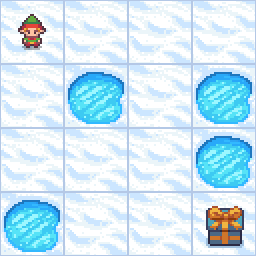

In [7]:
# MOTION_RECAP_COURSE09 — shared optional visual (FrozenLake GIF + step slider).

%pip install pillow ipywidgets -q

import pathlib
import sys

import numpy as np

for _d in [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]:
    if (_d / "course09_step_viz.py").exists():
        _course09 = _d
        break
else:
    raise FileNotFoundError(
        "Could not find course09_step_viz.py — open this notebook from inside Course 09 "
        "(normal Jupyter / Cursor layout) so parent folders include the Course 09 root."
    )

if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import gymnasium as gym
import course09_step_viz as cs9viz


def _random_policy(obs, step):
    return int(np.random.randint(0, 4))


env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="rgb_array")
frames, total_r, terminated, truncated = cs9viz.collect_rollout_frames(
    env, _random_policy, max_steps=48, seed=42
)
env.close()
print(
    f"Motion recap | return={total_r:.1f} | frames={len(frames)} | term={terminated} | trunc={truncated}"
)
cs9viz.display_gif(frames, duration_ms=110)
cs9viz.display_step_slider(frames, title="FrozenLake — timestep")


## Did you understand? (about 2 minutes)

<!-- STUDENT_SELF_CHECK_COURSE09 -->

Answer **without scrolling** first. Then scroll only to compare with the notebook.

1. **One sentence:** What is the *single main idea* you are supposed to carry to the next lesson?
2. **Trace one step:** Pick one moment from this notebook (a number you printed, a plot, a table, or a GIF/slider frame). Write **state → action → reward → next state** in your own words — even if your “state” is a vector or a tile index.
3. **One honest confusion:** Write one question you still have. That question is what you should bring to class, study group, or office hours.

**If any answer is blank:** run the notebook again from the top **slowly** (run one cell → read the output → only then run the next).

**Remember:** a clean run means the code worked — it does **not** automatically mean every idea clicked. Confusion is normal until you can do steps 1–2 in plain language.
